In [2]:
import ROOT as rt
import sys
import collections
from collections import OrderedDict
import uproot
import pandas as pd
import numpy as np

import scipy
import awkward
import time
import subprocess

GIT_REPO = subprocess.Popen(['git', 'rev-parse', '--show-toplevel'], stdout=subprocess.PIPE).communicate()[0].rstrip().decode('utf-8')
sys.path.append(GIT_REPO + '/lib/')
from histo_utilities import create_TH1D, create_TH2D, std_color_list, create_TGraph, make_ratio_plot
from helper_functions import L1_trg, deltaPhi

from scipy.stats import norm
import math
import CMS_lumi, tdrstyle
style = tdrstyle.setTDRStyle()
CMS_lumi.writeExtraText = 0


print(sys.version)

Welcome to JupyROOT 6.24/06
3.6.8 (default, Nov  2 2021, 13:01:57) 
[GCC 8.4.1 20200928 (Red Hat 8.4.1-1)]


# Load ntuples

In [14]:
%%time

fpath =OrderedDict()
tree = OrderedDict()

start_t = time.time()
version = "v30"

for data_year in ['all']:

    if data_year == 'all':path = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19//Data_all/{version}/normalized/'
    else: path = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19//Data{data_year}/{version}/normalized/'
    if data_year == '2022':fpath['data'+data_year] = path + "DisplacedJet-EXOCSCCluster_Run2022-PromptReco_goodLumi.root"
    elif data_year == '2023':fpath['data'+data_year] = path + "Muon-EXOCSCCluster_Run2023-PromptReco_goodLumi.root"
    elif data_year == '2024':fpath['data'+data_year] = path + "Muon-EXOCSCCluster_Run2024-PromptReco_goodLumi.root"
    elif data_year == 'all':fpath['data'+data_year] = path + "EXOCSCCluster_Run2022_2024_goodLumi.root"

fpath['sig_15'] = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_all/{version}/normalized/ggH_Hto2Sto4B_MH-125-MS-15-ctauS-1000_TuneCP5_13p6TeV_powheg-pythia8_50000pb_weighted.root'
fpath['sig_40'] = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_all/{version}/normalized/ggH_Hto2Sto4B_MH-125-MS-40-ctauS-1000_TuneCP5_13p6TeV_powheg-pythia8_50000pb_weighted.root'
fpath['sig_55'] = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_all/{version}/normalized/ggH_Hto2Sto4B_MH-125-MS-55-ctauS-1000_TuneCP5_13p6TeV_powheg-pythia8_50000pb_weighted.root'
# fpath['sig'] = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_all/{version}/normalized/ggH_Hto2Sto4B_MH-125-MS-55-ctauS-10000_TuneCP5_13p6TeV_powheg-pythia8_50000pb_weighted.root'
NEvents = {}

for k,v in fpath.items():
    print (k, v)
    root_dir = uproot.open(v) 

    tree[k] = root_dir['MuonSystem']
    NEvents[k] = root_dir['NEvents'].values()[0]
    # NEvents[k] = root_dir['NEvents'].counts()
    print("NEvents",NEvents[k])


dataall /storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19//Data_all/v22/normalized/EXOCSCCluster_Run2022_2024_goodLumi.root
NEvents 183102850.0
sig_15 /storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_all/v22/normalized/ggH_Hto2Sto4B_MH-125-MS-15-ctauS-1000_TuneCP5_13p6TeV_powheg-pythia8_50000pb_weighted.root
NEvents 57055616.0
sig_40 /storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_all/v22/normalized/ggH_Hto2Sto4B_MH-125-MS-40-ctauS-1000_TuneCP5_13p6TeV_powheg-pythia8_50000pb_weighted.root
NEvents 56700856.0
sig_55 /storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_all/v22/normalized/ggH_Hto2Sto4B_MH-125-MS-55-ctauS-1000_TuneCP5_13p6TeV_powheg-pythia8_50000pb_weighted.root
NEvents 58025490.0
CPU times: user 1.55 s, sys: 101 ms, total: 1.66 s
Wall time: 1.86 s


# apply selections

In [15]:
%%time

cscRechitClusterPhi = {}
cscRechitClusterSize = {}
dtRechitClusterPhi = {}
deltaPhi_cluster  = {}
cscRechitClusterDNN  = {}
dtRechitClusterSize  = {}
dtRechitClusterEta = {}
cscRechitClusterEta = {}
cscRechitClusterNStation = {}
cscRechitClusterMet_dPhi = {}
dtRechitClusterNStation = {}
dtRechitClusterBX  = {}
dtRechitClusterMet_dPhi = {}
deltaR_cluster = {}
deltaEta_cluster = {}
HMTEff = {}
weight = {}
runNum = {}
met = {}
dtRechitClusterMaxStation= {}
NStation = {}
dtRechitClusterOppSegSt1 = {}
dtRechitClusterOppSegSt2 = {}
dtRechitClusterOppSegSt3 = {}
dtRechitClusterOppSegSt4 = {}
            
dtRechitCluster_match_MB1hits_cosmics_plus = {}
dtRechitCluster_match_MB1hits_cosmics_minus = {}
# thresholds = {
# 'lowMET': [150,130,2.5],
# 'highMET': [100,180,2.5],}

thresholds = {
'lowMET': [160,130,2.6],
'highMET': [120,100,2.1],}
MET_THRESHOLD = 50
categories = ['lowMET','highMET']
# categories = ['lowMET']
region_list = ['invertDNN', 'oot', 'signal']
region_list = ['signal']
for region in region_list:
    for tree_k in tree.keys():
        T = tree[tree_k]
        
        for met_cat in categories:
            # if not (met_cat == 'highMET'):continue
            k = f'{region}_{tree_k}_{met_cat}'
            ########### SELECTION: CLUSTERS ############
            me1 = (T['cscRechitClusterNRechitChamberPlus11'].array()+ T['cscRechitClusterNRechitChamberPlus12'].array()+\
            T['cscRechitClusterNRechitChamberMinus11'].array()+ T['cscRechitClusterNRechitChamberMinus12'].array())

            #one cluster to pass trigger
            csccluster = np.logical_and(T['cscRechitClusterTimeWeighted'].array() < 12.5, T['cscRechitClusterTimeWeighted'].array() > -5)
            csccluster = csccluster & (me1 ==0)
            csccluster = csccluster & (T['cscRechitClusterTimeSpreadWeightedAll'].array()<20)
            csccluster = csccluster & (T['cscRechitClusterSize'].array()>thresholds[met_cat][0])
            csccluster = csccluster & (T['cscRechitClusterJetVetoPt'].array()<30)
            csccluster = csccluster & np.logical_not((T['cscRechitClusterMuonVetoPt'].array() > 30) & T['cscRechitClusterMuonVetoGlobal'].array())    


            dtcluster = (T['dtRechitClusterNHitStation1'].array()==0)
            dtcluster = dtcluster & (T['dtRechitCluster_match_RPChits_dPhi0p5'].array() >= 1)
            dtcluster = dtcluster & (T['dtRechitClusterJetVetoPt'].array()<30)
            dtcluster = dtcluster & np.logical_not((T['dtRechitClusterMuonVetoPt'].array() > 30) & T['dtRechitClusterMuonVetoLooseId'].array())

            ###cosmic veto for DT clusters###
            
            sel_cosmic = np.logical_and(T['dtRechitClusterNOppositeSegStation1'].array()>0, T['dtRechitClusterNOppositeSegStation2'].array()>0)
            sel_cosmic = np.logical_and(sel_cosmic, T['dtRechitClusterNOppositeSegStation3'].array()>0)
            sel_cosmic = np.logical_and(sel_cosmic, T['dtRechitClusterNOppositeSegStation4'].array()>0)
            sel_cosmic = np.logical_and(sel_cosmic, T['dtRechitClusterNOppositeSegStation1'].array()+T['dtRechitClusterNOppositeSegStation2'].array()+\
                                       T['dtRechitClusterNOppositeSegStation3'].array()+T['dtRechitClusterNOppositeSegStation4'].array()>=6)
            nstation = (T['dtRechitClusterNSegStation1'].array()>1)*1+(T['dtRechitClusterNSegStation2'].array()>1)*1\
            +(T['dtRechitClusterNSegStation3'].array()>1)*1+(T['dtRechitClusterNSegStation4'].array()>1)*1
            dtcluster = dtcluster & np.logical_not(np.logical_and(nstation>=3, sel_cosmic))
            
          
        
            
        ########### SELECTION: EVENTS ############
            sel_ev = T['HLT_CSCDT'].array()
            sel_ev = sel_ev & (T['nCscRechitClusters_nocut'].array()==1) & (T['nDtRechitClusters_nocut'].array()==1)
            if met_cat == 'lowMET':sel_ev = np.logical_and(sel_ev ,T['Puppimet'].array() < MET_THRESHOLD)
            else: sel_ev = np.logical_and(sel_ev ,T['Puppimet'].array() > MET_THRESHOLD)
            sel_ev = np.logical_and(sel_ev ,T['Puppimet'].array() < 200)
            sel_ev = np.logical_and(sel_ev ,T['Flag_all'].array())
            sel_ev = np.logical_and(sel_ev ,T['nCscRings'].array()+T['nDtRings'].array()<10)
            sel_ev  = sel_ev & (np.sum(dtcluster, axis = 1) == 1)
            sel_ev  = sel_ev & (np.sum(csccluster, axis = 1) == 1)
            
            sel_ev = np.logical_and(sel_ev ,T['jetVeto'].array())
            sel_ev = np.logical_and(sel_ev ,T['Flag_ecalBadCalibFilter'].array())
                
            print(k, np.count_nonzero(sel_ev))
        ########### BRANCHES ############

           ##### event variables ##### 
            # make sure cluster0 and cluster1 index are different

            cscRechitClusterPhi[k] = T['cscRechitClusterPhi'].array()[csccluster][sel_ev][:,0]
            dtRechitClusterPhi[k] = T['dtRechitClusterPhi'].array()[dtcluster][sel_ev][:,0]
            deltaPhi_cluster[k] = deltaPhi(np.array(cscRechitClusterPhi[k]), np.array(dtRechitClusterPhi[k]))

            cscRechitClusterDNN[k] = T['cscRechitClusterDNN_bkgMC_plusBeamHalo'].array()[csccluster][sel_ev][:,0]
            dtRechitClusterBX[k] = T['dtRechitCluster_match_RPCBx_dPhi0p5'].array()[dtcluster][sel_ev][:,0]
            dtRechitClusterSize[k] = T['dtRechitClusterSize'].array()[dtcluster][sel_ev][:,0]

            if "lowMET" in k: sel = (np.abs(deltaPhi_cluster[k])>1)
            else: sel = (np.abs(deltaPhi_cluster[k])>0.4)
            sel = (np.abs(deltaPhi_cluster[k])>0.4)
            
            if 'oot' in region:sel = sel & (cscRechitClusterDNN[k] > 0.96) & (dtRechitClusterBX[k]<0)
            elif 'invertDNN' in region: sel = sel & (cscRechitClusterDNN[k] < 0.96) & (dtRechitClusterBX[k] == 0)
            elif 'signal' in region:
                sel = sel & (cscRechitClusterDNN[k] > 0.96) & (dtRechitClusterBX[k] == 0)
                # if 'data' in k: sel = sel & (dtRechitClusterSize[k] < 100) & (np.abs(deltaPhi_cluster[k]) < 2.8)
            else: assert(False)


            print(k, np.count_nonzero(sel))
            cscRechitClusterSize[k] = T['cscRechitClusterSize'].array()[csccluster][sel_ev][sel][:,0]
            cscRechitClusterEta[k] = T['cscRechitClusterEta'].array()[csccluster][sel_ev][sel][:,0]
            dtRechitClusterEta[k] = T['dtRechitClusterEta'].array()[dtcluster][sel_ev][sel][:,0]
            
            cscRechitClusterPhi[k] = T['cscRechitClusterPhi'].array()[csccluster][sel_ev][sel][:,0]
            dtRechitClusterPhi[k] = T['dtRechitClusterPhi'].array()[dtcluster][sel_ev][sel][:,0]
            
            
            cscRechitClusterNStation[k] = T['cscRechitClusterNStation10'].array()[csccluster][sel_ev][sel][:,0]
            dtRechitClusterNStation[k] = T['dtRechitClusterNStation10'].array()[dtcluster][sel_ev][sel][:,0]
            cscRechitClusterDNN[k] = T['cscRechitClusterDNN_bkgMC_plusBeamHalo'].array()[csccluster][sel_ev][sel][:,0]
            dtRechitCluster_match_MB1hits_cosmics_plus[k] = T['dtRechitCluster_match_MB1hits_cosmics_plus'].array()[dtcluster][sel_ev][sel][:,0]
            dtRechitCluster_match_MB1hits_cosmics_minus[k] = T['dtRechitCluster_match_MB1hits_cosmics_minus'].array()[dtcluster][sel_ev][sel][:,0]
            dtRechitClusterBX[k] = T['dtRechitCluster_match_RPCBx_dPhi0p5'].array()[dtcluster][sel_ev][sel][:,0]
            dtRechitClusterMaxStation[k] = T['dtRechitClusterMaxStation'].array()[dtcluster][sel_ev][sel][:,0]

            

        
            deltaPhi_cluster[k] = deltaPhi_cluster[k][sel]
            met[k] = T['met'].array()[sel_ev][sel]
            cscRechitClusterMet_dPhi[k] = T['cscRechitClusterMet_dPhi'].array()[csccluster][sel_ev][sel][:,0]
            dtRechitClusterMet_dPhi[k] = T['dtRechitClusterMet_dPhi'].array()[dtcluster][sel_ev][sel][:,0]
            runNum[k] = T['runNum'].array()[sel_ev][sel]
            deltaR_cluster[k] = ((cscRechitClusterEta[k]-dtRechitClusterEta[k])**2 + deltaPhi_cluster[k]**2)**0.5
            deltaEta_cluster[k] = cscRechitClusterEta[k]-dtRechitClusterEta[k]
            dtRechitClusterSize[k] = dtRechitClusterSize[k][sel]
            HMTEff[k] = T['cscRechitClusterHMTEfficiency'].array()[sel_ev][sel][:,0]
            weight[k] = (T['pileupWeight'].array()*T['weight'].array())[sel_ev][sel]*HMTEff[k]
            if 'data' in k:weight[k] = T['weight'].array()[sel_ev][sel]*0.0 + 1
            print(k,len(weight[k]),np.sum(weight[k]))
            if np.count_nonzero(sel)<=1:continue
            print("correlation between two variables:", k, scipy.stats.pearsonr(deltaPhi_cluster[k], dtRechitClusterSize[k]))
            print("events in this region:", k, len(deltaPhi_cluster[k]))

signal_dataall_lowMET 11552
signal_dataall_lowMET 917
signal_dataall_lowMET 917 917.0
correlation between two variables: signal_dataall_lowMET (-0.011506111418236521, 0.7278669044452148)
events in this region: signal_dataall_lowMET 917
signal_dataall_highMET 1478
signal_dataall_highMET 85
signal_dataall_highMET 85 85.0
correlation between two variables: signal_dataall_highMET (-0.10026350883035963, 0.36124225759586487)
events in this region: signal_dataall_highMET 85
signal_sig_15_lowMET 1801
signal_sig_15_lowMET 1613
signal_sig_15_lowMET 1613 1377.1008
correlation between two variables: signal_sig_15_lowMET (-0.019605780888512014, 0.4313544968852363)
events in this region: signal_sig_15_lowMET 1613
signal_sig_15_highMET 883
signal_sig_15_highMET 739
signal_sig_15_highMET 739 647.40063
correlation between two variables: signal_sig_15_highMET (-0.021821298830297983, 0.5536707120300801)
events in this region: signal_sig_15_highMET 739
signal_sig_40_lowMET 27
signal_sig_40_lowMET 22
signa

In [13]:
for k in weight.keys():
    print(k, np.sum(weight[k]))

invertDNN_dataall_lowMET 821.0
invertDNN_dataall_highMET 125.0
oot_dataall_lowMET 637.0
oot_dataall_highMET 105.0
signal_dataall_lowMET 917.0
signal_dataall_highMET 85.0


In [ ]:
v22

invertDNN_dataall_lowMET 821.0
invertDNN_dataall_highMET 125.0
oot_dataall_lowMET 637.0
oot_dataall_highMET 105.0
signal_dataall_lowMET 917.0
signal_dataall_highMET 85.0


old

invertDNN_dataall_lowMET 605.0
invertDNN_dataall_highMET 1179.0
invertDNN_sig_lowMET 0.86407954
invertDNN_sig_highMET 14.806614
oot_dataall_lowMET 490.0
oot_dataall_highMET 823.0
oot_sig_lowMET 0.0
oot_sig_highMET 0.2234029
signal_dataall_lowMET 689.0
signal_dataall_highMET 827.0
signal_sig_lowMET 16.188862
signal_sig_highMET 98.821205

80 23 127
80 0.15333333333333332
90 13 86
90 0.13131313131313133
100 11 60
100 0.15492957746478872
110 9 46
110 0.16363636363636364
120 5 33
120 0.13157894736842105
130 2 24
130 0.07692307692307693
140 2 20
140 0.09090909090909091
1.2827584743499756


Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: 

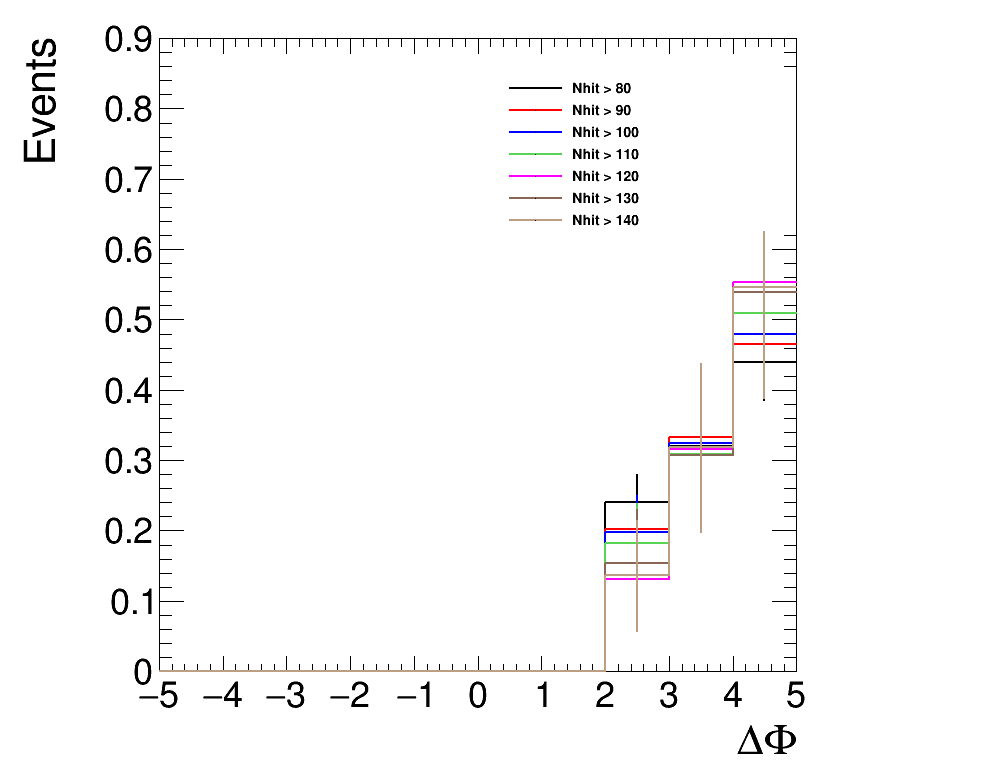

In [5]:
start_t = time.time()
c = rt.TCanvas('c','c', 1000, 800)
h = {}
leg = rt.TLegend(0.5,0.7,0.8,0.9)
leg.SetBorderSize(0)
plot_var = [runNum,dtRechitClusterSize, deltaPhi_cluster, cscRechitClusterEta,cscRechitClusterSize,cscRechitClusterNStation, dtRechitClusterNStation, cscRechitClusterDNN, deltaR_cluster, met, cscRechitClusterPhi, dtRechitClusterPhi]
axis = ["runNum", 'N_{dt rechits}','#Delta#phi','csc cluster #eta','N_{csc rechits}', 'csc cluster N_{station 10}', 'dt cluster N_{station 10}', 'cscRechitClusterDNN','deltaR', 'met', 'cscRechitClusterPhi','dtRechitClusterPhi']
name = ['nhits','dphi','cscRechitClusterEta','cscRechitClusterSize','cscRechitClusterNStation10', 'dtRechitClusterNStation10', 'cscRechitClusterDNN','deltaR_cluster','met', 'cscRechitClusterPhi', 'dtRechitClusterPhi']
bins = [[1000, 360019, 387121],[25,0,500],[25,0,3.2],[50,1,2.5],[50,0,800],[5,0,5], [5,0,5], [50,0.5,1], [50,0,4],[50,0,200], [50,-4,4], [50,-4,4]]

plot_index = 3
i = 0
k = 'oot_dataall_lowMET'
DPHI_CUT =2.5
nhit = 50
for nhit_threshold in np.arange(80,150,10):
    # cond = (np.abs(deltaPhi_cluster[k])>1) & (cscRechitClusterDNN[k]>0.9)
    cond = (np.abs(deltaPhi_cluster[k])>=0) 
    # cond = cond & (dtRechitClusterSize[k]>=nhit) & (dtRechitClusterSize[k]<nhit_threshold)
    cond = cond & (dtRechitClusterSize[k]>=nhit_threshold)
    h[nhit_threshold] = create_TH1D( np.abs(np.array(deltaPhi_cluster[k][cond])), axis_title = ["#Delta#Phi",'Events'], binning=[25,0,3.2], weights = np.array(weight[k][cond]))
    # h[nhit_threshold] = create_TH1D( np.array(dtRechitClusterEta[k][cond]), axis_title = ["#Delta#eta",'Events'], binning=[25,-1,1], weights = np.array(weight[k][cond]))
    # h[nhit_threshold] = create_TH1D( np.array(dtRechitClusterBX[k][cond]), axis_title = ["#Delta#Phi",'Events'], binning=[20,-10,10], weights = np.array(weight[k][cond]))
    h[nhit_threshold] = create_TH1D( np.array(dtRechitClusterMaxStation[k][cond]), axis_title = ["#Delta#Phi",'Events'], binning=[10,-5,5], weights = np.array(weight[k][cond]))
    if h[nhit_threshold].Integral()>0: h[nhit_threshold].Scale(1./h[nhit_threshold].Integral())
    h[nhit_threshold].SetLineColor(std_color_list[i])
    h[nhit_threshold].SetMaximum(0.9)
    print(nhit_threshold, np.count_nonzero(np.abs(np.array(deltaPhi_cluster[k][cond]))>=DPHI_CUT), np.count_nonzero(np.abs(np.array(deltaPhi_cluster[k][cond]))<DPHI_CUT))
    print(nhit_threshold, np.count_nonzero(np.abs(np.array(deltaPhi_cluster[k][cond]))>=DPHI_CUT)/np.count_nonzero(cond))
    leg.AddEntry(h[nhit_threshold],f"Nhit > {nhit_threshold}")
    h[nhit_threshold].Draw('histE same')
    i+=1
    # nhit = nhit_threshold

    
leg.Draw()
if plot_index == 0 or plot_index == 3 or plot_index == 8:c.SetLogy()
c.SetRightMargin(0.2)
# c.SetLogy()
c.Draw()

print(time.time()-start_t)

# Plot 1D distributions

signal_sig_15_lowMET 0.9125852448853069
signal_sig_15_highMET 0.918809201623816
signal_sig_40_lowMET 0.9090909090909091
signal_sig_40_highMET 0.8181818181818182
0.21849584579467773


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Info in <TCanvas::Print>: png file /storage/af/user/christiw/l

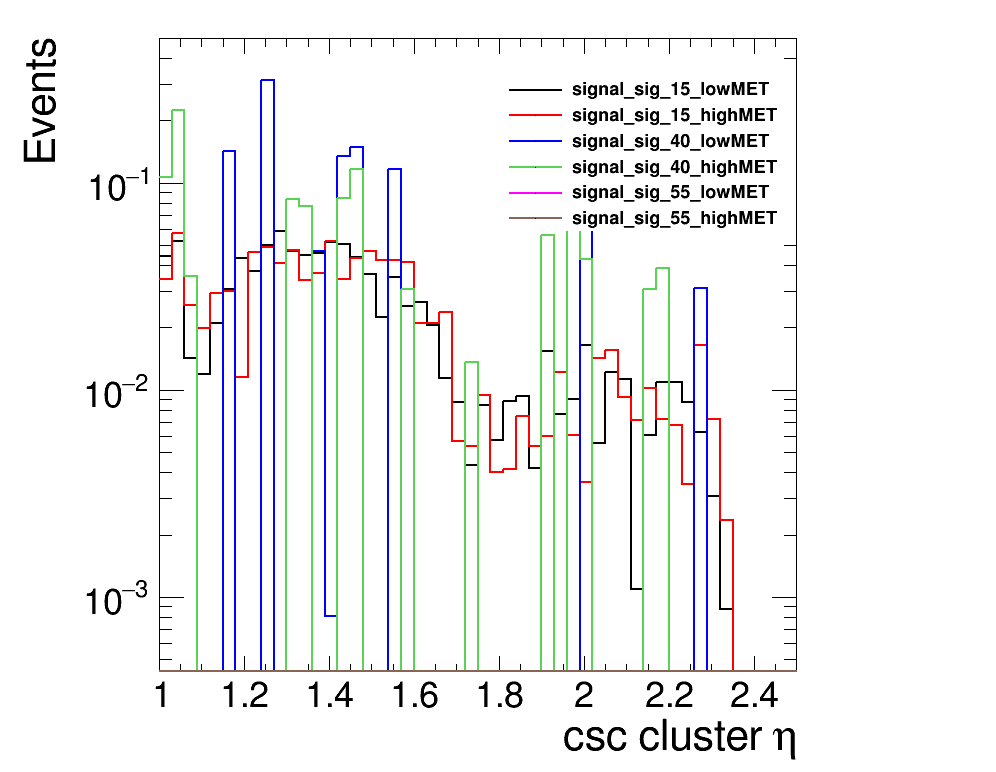

In [17]:
start_t = time.time()
c = rt.TCanvas('c','c', 1000, 800)
h = {}
leg = rt.TLegend(0.5,0.7,0.8,0.9)
leg.SetBorderSize(0)
plot_var = [runNum,dtRechitClusterSize, deltaPhi_cluster, cscRechitClusterEta,cscRechitClusterSize,cscRechitClusterNStation, dtRechitClusterNStation, cscRechitClusterDNN, deltaR_cluster, met, cscRechitClusterPhi, dtRechitClusterPhi]
axis = ["runNum", 'N_{dt rechits}','#Delta#phi','csc cluster #eta','N_{csc rechits}', 'csc cluster N_{station 10}', 'dt cluster N_{station 10}', 'cscRechitClusterDNN','deltaR', 'met', 'cscRechitClusterPhi','dtRechitClusterPhi']
name = ['nhits','dphi','cscRechitClusterEta','cscRechitClusterSize','cscRechitClusterNStation10', 'dtRechitClusterNStation10', 'cscRechitClusterDNN','deltaR_cluster','met', 'cscRechitClusterPhi', 'dtRechitClusterPhi']
bins = [[1000, 360019, 387121],[25,0,500],[25,0,3.2],[50,1,2.5],[50,0,800],[5,0,5], [5,0,5], [50,0.5,1], [50,0,4],[50,0,200], [50,-4,4], [50,-4,4]]

plot_index = 3
i = 0
for k in plot_var[plot_index].keys():

    # if 'signal_dataall' in k:continue
    # if not "OOT" in k and  not "signal" in k:continue
    # if 'invertDNN_sig' in k or 'oot_sig' in k:continue
    if not "signal_si" in k:continue
    # if not "oot_dataall_lowMET" in k:continue
    cond = cscRechitClusterSize[k]>0
    # cond = cond & (np.abs(dtRechitClusterMaxStation[k])==4)
    h[k] = create_TH1D( np.abs(np.array(plot_var[plot_index][k][cond])), axis_title = [axis[plot_index],'Events'], binning=bins[plot_index], weights = np.array(weight[k][cond]))
    h[k] = create_TH1D( np.array(plot_var[plot_index][k][cond]), axis_title = [axis[plot_index],'Events'], binning=bins[plot_index], weights = np.array(weight[k][cond]))
    if np.count_nonzero(cond)>0:print(k, np.count_nonzero(np.array(plot_var[plot_index][k][cond])<1.9)/np.count_nonzero(cond))
    if h[k].Integral()>0:h[k].Scale(1./h[k].Integral())
    h[k].SetLineColor(std_color_list[i])
    h[k].SetMaximum(0.5)
    # if "signal_data" in k:leg.AddEntry(h[k],'SR_data (region C)_' + k.split('_')[-1])
    # else:     leg.AddEntry(h[k],k.replace('all','').replace('_lowMET',''))

    leg.AddEntry(h[k],k)
    h[k].Draw('hist same')
    i+=1

    
leg.Draw()
if plot_index == 0 or plot_index == 3 or plot_index == 8:c.SetLogy()
c.SetRightMargin(0.2)
# c.SetLogy()
c.Draw()

c.SaveAs(GIT_REPO + "/plots/ABCD/"+name[plot_index]+"_dtcsc.png")
c.SaveAs(GIT_REPO + "/plots/ABCD/"+name[plot_index]+"_dtcsc.pdf")
c.SaveAs(GIT_REPO + "/plots/ABCD/"+name[plot_index]+"_dtcsc.C")


print(time.time()-start_t)

# 2D distribution of dphi and Nrechits

invertDNN_dataall_lowMET 285.0
invertDNN_dataall_highMET 109.0
invertDNN_sig_lowMET 1.3256291
invertDNN_sig_highMET 12.622149
oot_dataall_lowMET 192.0
oot_dataall_highMET 76.0
oot_dataall_highMET 131.0 131
oot_sig_lowMET 0.0
oot_sig_highMET 0.2234029
signal_dataall_lowMET 272.0
signal_dataall_highMET 66.0
signal_sig_lowMET 6.5651903
signal_sig_highMET 91.27351
0.35348987579345703


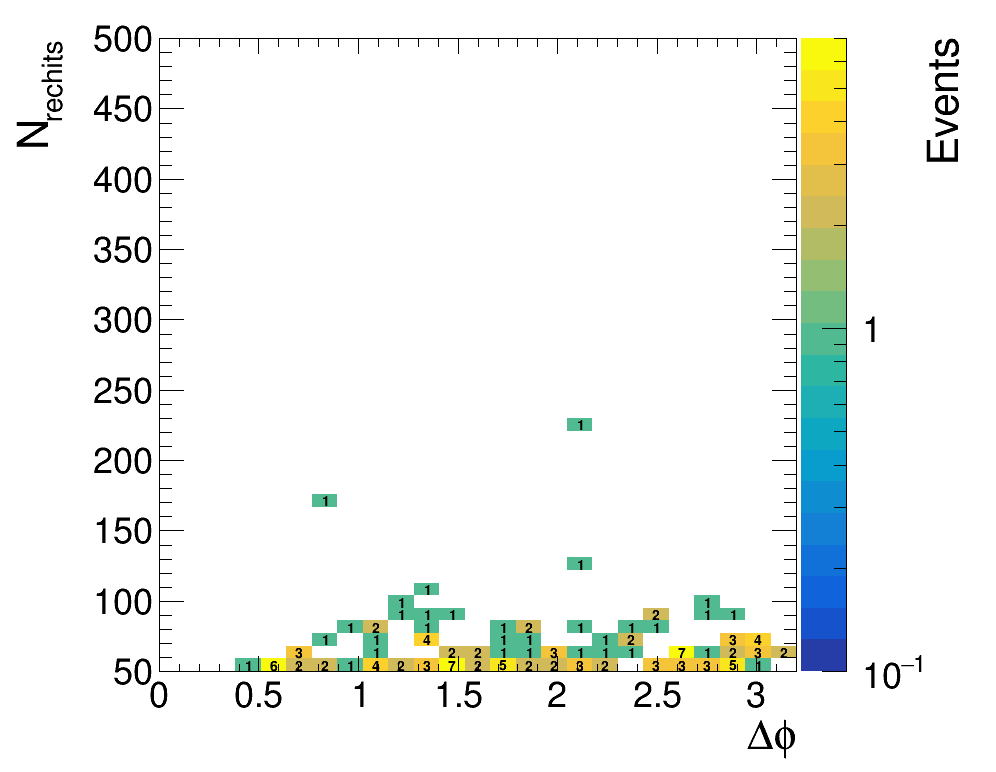

In [15]:
start_t = time.time()
c = rt.TCanvas('c','c', 1000, 800)

for k in dtRechitClusterSize.keys():
    print(k, np.sum(weight[k][met[k]>50]))
    # if not k == "oot_dataall_lowMET":continue
    if not k == "oot_dataall_highMET":continue
    cond = (np.abs(dtRechitClusterMaxStation[k])>0)
    h = create_TH2D(np.column_stack(( np.abs(deltaPhi_cluster[k]), np.array(dtRechitClusterSize[k]), )),
                   axis_title = ['#Delta#phi','N_{rechits}','Events'], binning=[25,0,3.2,50,50,500,])
    # h = create_TH2D(np.column_stack(( np.abs(deltaPhi_cluster[k][cond]), np.array(deltaEta_cluster[k][cond]))),
                   # axis_title = ['#Delta#phi','#Delta#eta','Events'], binning=[25,0,3.2,50,-5,5,])
    
    # h = create_TH2D(np.column_stack(( np.array(dtRechitClusterEta[k]), np.array(dtRechitClusterPhi[k]), )),
    #                axis_title = ['DT cluster #eta', 'DT cluster #phi','Events'], binning=[25,-1.1,1.1,25,-3.2,3.2,])
    # h = create_TH2D(np.column_stack(( np.array(cscRechitClusterEta[k]), np.array(cscRechitClusterPhi[k]), )),
                   # axis_title = ['CSC cluster #eta', 'CSC cluster #phi','Events'], binning=[80,-2.5,2.5,25,-3.2,3.2,])
    # h = create_TH2D(np.column_stack(( np.abs(deltaPhi_cluster[k]), np.array(met[k]), )),
    #                axis_title = ['#Delta#phi','met','Events'], binning=[25,0,3.2,50,0,500,])

    h.SetMinimum(0.1)
    h.Draw('colz text')
    c.SetRightMargin(0.2)

    print(k, h.Integral(), len(dtRechitClusterSize[k]))
    # if setlog: 
    c.SetLogz()
    c.Draw('')

#     c.SaveAs(GIT_REPO + "/plots/ABCD/dtcsc_"+k+".png")
#     c.SaveAs(GIT_REPO + "/plots/ABCD/dtcsc_"+k+".pdf")
#     c.SaveAs(GIT_REPO + "/plots/ABCD/dtcsc_"+k+".C")
    



print(time.time()-start_t)

# ABCD (Scan Nrechits)

In [14]:
a = {}
b = {}
c = {}
d = {}
cuts = np.arange(50,106,1)
# cuts = np.arange(60,300,10)

cuts = np.arange(90,150,10)
n_ev = 5000

table = {}
latex_table = {}

# cuts = [90,95,100,104,105]
print(cuts)
bkg_dphiJet = []
sig_dphiJet = []
bkg_dphiCluster = []
sig_dphiCluster = []
print_jetmet = 0

for k in dtRechitClusterSize.keys():
    if 'sig' in k:continue
    print("*****************************")
    print(f"******** {k} **********")
    print("*****************************")
    table[k] = {
        # "dPhi cuts": ['dphi', 'A', 'B', 'C', 'D', 'prediction', 'uncertainty'],
        "Nhits cuts":[],
        "A": [],
        "B": [],
        "C": [],
        "D": [],
        "pred":[],
        "uncertainty":[],
    }
    if "lowMET" in k: 
        DPHI_CUT = thresholds["lowMET"][-1]
        cuts =  [thresholds["lowMET"][1]]
    else: 
        DPHI_CUT = thresholds["highMET"][-1]
        cuts = [thresholds["highMET"][1]]
    print(f"DPHI_CUT:{DPHI_CUT}")
    for N_RECHIT_CUT in cuts:
        if N_RECHIT_CUT<80:continue
        
        cond = (cscRechitClusterDNN[k]>=0.9) 
        if "lowMET" in k: cond = cond & (np.abs(deltaPhi_cluster[k]) > 1)
        var = np.abs(deltaPhi_cluster[k])
        
        a[k] = np.count_nonzero([cond & np.logical_and(dtRechitClusterSize[k]>=N_RECHIT_CUT, var>=DPHI_CUT)])
        b[k] = np.count_nonzero([cond & np.logical_and(dtRechitClusterSize[k]>=N_RECHIT_CUT, var<DPHI_CUT)])
        c[k] = np.count_nonzero([cond & np.logical_and(dtRechitClusterSize[k]<N_RECHIT_CUT, var<DPHI_CUT)])
        d[k] = np.count_nonzero([cond & np.logical_and(dtRechitClusterSize[k]<N_RECHIT_CUT, var>=DPHI_CUT)])

        if b[k] == 0 or c[k] == 0 or d[k] ==0:break
        pred = b[k]*d[k]/c[k]
        unc_pred = (1./c[k] + 1./b[k] + 1./d[k])**0.5*pred
        if math.isnan(unc_pred): z_value = float("nan")
        else:
            mu = np.random.normal(pred, unc_pred, n_ev)
            p_value = 0.0
            for i in mu:
                if i < 0:continue
                n = np.random.poisson(i, n_ev)
                p_value += np.count_nonzero(n>=a[k])

            p_value = p_value/n_ev**2
            z_value = abs(norm.ppf(p_value))
        print(N_RECHIT_CUT, '\t',a[k],'\t',b[k],'\t',c[k],'\t',d[k],'\t', round(pred, 2), '\t',\
              round( unc_pred, 2), '\t', round(z_value,2))
        
        
        table[k]['Nhits cuts'].append(N_RECHIT_CUT)
        table[k]['A'].append(a[k])
        table[k]['B'].append(b[k])
        table[k]['C'].append(c[k])
        table[k]['D'].append(d[k])
        table[k]['pred'].append(pred)
        table[k]['uncertainty'].append(unc_pred)
        
        
    # write to latex format for AN
    table[k] = pd.DataFrame(table[k])
    latex_table[k] = table[k].to_latex(
    index=False,  # To not include the DataFrame index as a column in the table
    column_format="|l|l|l|l|l|",  # The format of the columns: left-aligned with vertical lines between them
    escape=False,  # Disable escaping LaTeX special characters in the DataFrame
    float_format="{:0.2f}".format  # Formats floats to two decimal places
    )
    print(latex_table[k])


[ 90 100 110 120 130 140]
*****************************
******** invertDNN_dataall_lowMET **********
*****************************
DPHI_CUT:2.6
130 	 2 	 6 	 230 	 47 	 1.23 	 0.54 	 0.4
\begin{tabular}{|l|l|l|l|l|}
\toprule
 Nhits cuts &  A &  B &    C &   D &  pred &  uncertainty \\
\midrule
        130 &  2 &  6 &  230 &  47 &  1.23 &         0.54 \\
\bottomrule
\end{tabular}

*****************************
******** invertDNN_dataall_highMET **********
*****************************
DPHI_CUT:2.1
100 	 1 	 3 	 41 	 18 	 1.32 	 0.85 	 0.35
\begin{tabular}{|l|l|l|l|l|}
\toprule
 Nhits cuts &  A &  B &   C &   D &  pred &  uncertainty \\
\midrule
        100 &  1 &  3 &  41 &  18 &  1.32 &         0.85 \\
\bottomrule
\end{tabular}

*****************************
******** oot_dataall_lowMET **********
*****************************
DPHI_CUT:2.6
130 	 2 	 15 	 403 	 97 	 3.61 	 1.02 	 0.99
\begin{tabular}{|l|l|l|l|l|}
\toprule
 Nhits cuts &  A &   B &    C &   D &  pred &  uncertainty \\
\mid

In [15]:
VR_keys = [x.replace("_dataall_", " ") for x in table.keys()]
VR_keys = [x.replace("invert", "inverted ") for x in VR_keys]
VR_keys = [x.replace("lowMET", "low MET bin (MET $< $50 \GeV)") for x in VR_keys]
VR_keys = [x.replace("highMET", "high MET bin (MET $\geq$50 \GeV)") for x in VR_keys]
VR_keys = [x.replace("oot", " OOT") for x in VR_keys]

print(VR_keys)
all_table = pd.concat(table.values(), keys=VR_keys)
all_table =all_table.reset_index()
all_table = all_table[["level_0", "A", "B","C","D", "pred", "uncertainty"]]
print(all_table.head())
all_table = all_table.to_latex(
    header = ["validation region", "A", "B","C","D", "prediction", "uncertainty"],
    index=False,  # To not include the DataFrame index as a column in the table
    column_format="l|l|l|l|l|l|l",  # The format of the columns: left-aligned with vertical lines between them
    escape=False,  # Disable escaping LaTeX special characters in the DataFrame
    float_format="{:0.2f}".format,  # Formats floats to two decimal places
    caption = "Validation of the background estimation method for low MET DT-CSC category.\
    The uncertainty of the prediction is the statistical uncertainty propogated from bin B, C, and D.",
    label = "tab:validation_lowMET_DTCSC",
    )
print(all_table.replace("midrule","hline"))

['inverted DNN low MET bin (MET $< $50 \\GeV)', 'inverted DNN high MET bin (MET $\\geq$50 \\GeV)', ' OOT low MET bin (MET $< $50 \\GeV)', ' OOT high MET bin (MET $\\geq$50 \\GeV)']
                                         level_0  A   B    C   D      pred  \
0     inverted DNN low MET bin (MET $< $50 \GeV)  2   6  230  47  1.226087   
1  inverted DNN high MET bin (MET $\geq$50 \GeV)  1   3   41  18  1.317073   
2              OOT low MET bin (MET $< $50 \GeV)  2  15  403  97  3.610422   
3           OOT high MET bin (MET $\geq$50 \GeV)  2   1   56  46  0.821429   

   uncertainty  
0     0.537651  
1     0.846704  
2     1.017712  
3     0.837533  
\begin{table}
\centering
\caption{Validation of the background estimation method for low MET DT-CSC category.    The uncertainty of the prediction is the statistical uncertainty propogated from bin B, C, and D.}
\label{tab:validation_lowMET_DTCSC}
\begin{tabular}{l|l|l|l|l|l|l}
\toprule
                             validation region &  A &  

In [ ]:
\begin{table}
\centering
\caption{Validation of the background estimation method for low MET DT-CSC category.    The uncertainty of the prediction is the statistical uncertainty propogated from bin B, C, and D.}
\label{tab:validation_lowMET_DTCSC}
\begin{tabular}{l|l|l|l|l|l|l}
\toprule
                             validation region &  A &   B &    C &   D & prediction & uncertainty \\
\hline
    inverted DNN low MET bin (MET $< $50 \GeV) &  2 &   6 &  229 &  47 &       1.23 &        0.54 \\
 inverted DNN high MET bin (MET $\geq$50 \GeV) &  1 &   3 &   41 &  18 &       1.32 &        0.85 \\
             OOT low MET bin (MET $< $50 \GeV) &  2 &  15 &  405 &  97 &       3.59 &        1.01 \\
          OOT high MET bin (MET $\geq$50 \GeV) &  2 &   1 &   56 &  46 &       0.82 &        0.84 \\
\bottomrule
\end{tabular}
\end{table}


# ABCD (Scan dPhi)

In [5]:

a = {}
b = {}
c = {}
d = {}
cuts = np.arange(50,106,1)
cuts = np.arange(0,35,2)/10
cuts = np.arange(1.8,3.2,0.05)
print(cuts)
n_ev = 1000


table = {}
latex_table = {}

N_RECHIT_CUT = 90
for k in dtRechitClusterSize.keys():
    if 'sig' in k:continue
    
    table[k] = {
        # "dPhi cuts": ['dphi', 'A', 'B', 'C', 'D', 'prediction', 'uncertainty'],
        "dPhi cuts":[],
        "A": [],
        "B": [],
        "C": [],
        "D": [],
        "pred":[],
        "uncertainty":[],
    }
    print("*****************************")
    print(f"******** {k} **********")
    print("*****************************")
    for DPHI_CUT in cuts:
        var = np.abs(deltaPhi_cluster[k])
        
        a[k] = np.count_nonzero([np.logical_and(dtRechitClusterSize[k]>=N_RECHIT_CUT, var>=DPHI_CUT)])
        b[k] = np.count_nonzero([np.logical_and(dtRechitClusterSize[k]>=N_RECHIT_CUT, var<DPHI_CUT)])
        c[k] = np.count_nonzero([np.logical_and(dtRechitClusterSize[k]<N_RECHIT_CUT, var<DPHI_CUT)])
        d[k] = np.count_nonzero([np.logical_and(dtRechitClusterSize[k]<N_RECHIT_CUT, var>=DPHI_CUT)])


        if b[k] == 0 or c[k] == 0 or d[k] ==0:continue
        pred = b[k]*d[k]/c[k]
        unc_pred = (1./c[k] + 1./b[k] + 1./d[k])**0.5*pred
        if math.isnan(unc_pred): z_value = float("nan")
        else:
            mu = np.random.normal(pred, unc_pred, n_ev)
            p_value = 0.0
            for i in mu:
                if i < 0:continue
                n = np.random.poisson(i, n_ev)
                p_value += np.count_nonzero(n>=a[k])

            p_value = p_value/n_ev**2
            z_value = abs(norm.ppf(p_value))
        print(round(DPHI_CUT,2), '\t',a[k],'\t',b[k],'\t',c[k],'\t',d[k],'\t', round(pred, 2), '\t',\
              round( unc_pred, 2), '\t', round(z_value,2))
        # table[k][DPHI_CUT] = [DPHI_CUT, int(a[k]),b[k],c[k],d[k],pred,unc_pred]

        
        table[k]['dPhi cuts'].append(DPHI_CUT)
        table[k]['A'].append(a[k])
        table[k]['B'].append(b[k])
        table[k]['C'].append(c[k])
        table[k]['D'].append(d[k])
        table[k]['pred'].append(pred)
        table[k]['uncertainty'].append(unc_pred)
        
        
        
    table[k] = pd.DataFrame(table[k])
    latex_table[k] = table[k].to_latex(
    index=False,  # To not include the DataFrame index as a column in the table
    column_format="|l|l|l|l|l|",  # The format of the columns: left-aligned with vertical lines between them
    escape=False,  # Disable escaping LaTeX special characters in the DataFrame
    float_format="{:0.2f}".format  # Formats floats to two decimal places
    )

    print(latex_table[k])


[1.8  1.85 1.9  1.95 2.   2.05 2.1  2.15 2.2  2.25 2.3  2.35 2.4  2.45
 2.5  2.55 2.6  2.65 2.7  2.75 2.8  2.85 2.9  2.95 3.   3.05 3.1  3.15]
*****************************
******** invertDNN_dataall_lowMET **********
*****************************
1.8 	 80 	 154 	 575 	 485 	 129.9 	 13.18 	 3.14
1.85 	 75 	 159 	 596 	 464 	 123.79 	 12.45 	 3.19
1.9 	 71 	 163 	 618 	 442 	 116.58 	 11.67 	 3.22
1.95 	 68 	 166 	 639 	 421 	 109.37 	 10.92 	 3.01
2.0 	 63 	 171 	 656 	 404 	 105.31 	 10.45 	 3.32
2.05 	 61 	 173 	 667 	 393 	 101.93 	 10.1 	 3.13
2.1 	 55 	 179 	 691 	 369 	 95.59 	 9.44 	 3.21
2.15 	 51 	 183 	 709 	 351 	 90.6 	 8.93 	 3.38
2.2 	 50 	 184 	 728 	 332 	 83.91 	 8.32 	 2.97
2.25 	 46 	 188 	 746 	 314 	 79.13 	 7.85 	 3.11
2.3 	 44 	 190 	 761 	 299 	 74.65 	 7.44 	 3.05
2.35 	 41 	 193 	 778 	 282 	 69.96 	 7.0 	 2.91
2.4 	 41 	 193 	 796 	 264 	 64.01 	 6.47 	 2.49
2.45 	 38 	 196 	 813 	 247 	 59.55 	 6.07 	 2.36
2.5 	 35 	 199 	 827 	 233 	 56.07 	 5.75 	 2.47
2.